In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("googleplaystore.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (10841, 13)


In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [5]:
print(df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [6]:
df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
## Missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [9]:
## Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 483


In [11]:
## Check columns
print("Number of columns:", len(df.columns))
print("Columns:")
for col in df.columns:
    print(col)

Number of columns: 13
Columns:
App
Category
Rating
Reviews
Size
Installs
Type
Price
Content Rating
Genres
Last Updated
Current Ver
Android Ver


In [12]:
## Remove Duplicate Apps

print("Before removing duplicates:", df.shape)

df = df.drop_duplicates(subset=['App'], keep='first')

print("After removing duplicates:", df.shape)

print("Duplicate apps remaining:", df['App'].duplicated().sum())

Before removing duplicates: (10841, 13)
After removing duplicates: (9660, 13)
Duplicate apps remaining: 0


In [14]:
## Check Missing Values Again
print(df.isnull().sum())

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [15]:
## Handle Rating Missing Values
## Rating mein bohat missing values hain.

df['Rating'] = df['Rating'].fillna(
    df['Rating'].median()
)

print("Missing Rating values:",
      df['Rating'].isnull().sum())

Missing Rating values: 0


In [16]:
## Handle Type

df['Type'] = df['Type'].fillna(
    df['Type'].mode()[0]
)


print("Missing Type values:",
      df['Type'].isnull().sum())

Missing Type values: 0


In [17]:
## Handle Content Rating
df['Content Rating'] = df['Content Rating'].fillna(
    df['Content Rating'].mode()[0]
)


print(
    "Missing Content Rating values:",
    df['Content Rating'].isnull().sum()
)

Missing Content Rating values: 0


In [18]:
## Handle Current Version
df['Current Ver'] = df['Current Ver'].fillna(
    df['Current Ver'].mode()[0]
)


print(
    "Missing Current Ver values:",
    df['Current Ver'].isnull().sum()
)

Missing Current Ver values: 0


In [20]:
## Handle Android Version
df['Android Ver'] = df['Android Ver'].fillna(
    df['Android Ver'].mode()[0]
)


print(
    "Missing Android Ver values:",
    df['Android Ver'].isnull().sum()
)

Missing Android Ver values: 0


In [21]:
## Final Missing Value Check
print("Missing values after cleaning:")


print(
    df.isnull().sum()
)

Missing values after cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


In [22]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0


In [23]:
## Basic Statistics

df.describe()

,Rating
count,9660.000000
mean,4.193975
std,0.518732
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


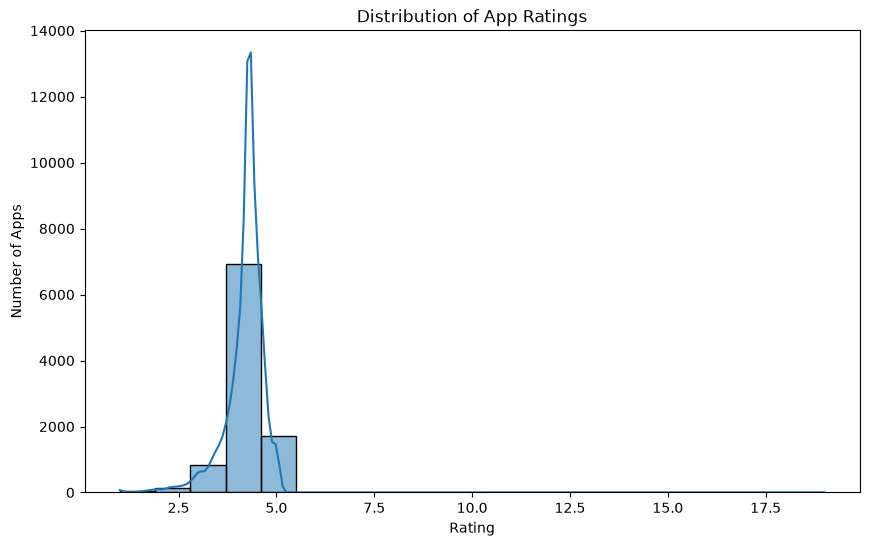

In [24]:
## Rating Distribution
plt.figure(figsize=(10, 6))


sns.histplot(
    df['Rating'],
    bins=20,
    kde=True
)


plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')


plt.show()

In [ ]:
## Rating Distribution

The rating distribution shows how user ratings are distributed across the Google Play Store applications.

Most applications have ratings concentrated in the higher range, while relatively fewer applications have very low ratings.

In [25]:
## Top Categories
category_counts = df['Category'].value_counts()


print("Top 10 App Categories:")
print(category_counts.head(10))

Top 10 App Categories:
Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


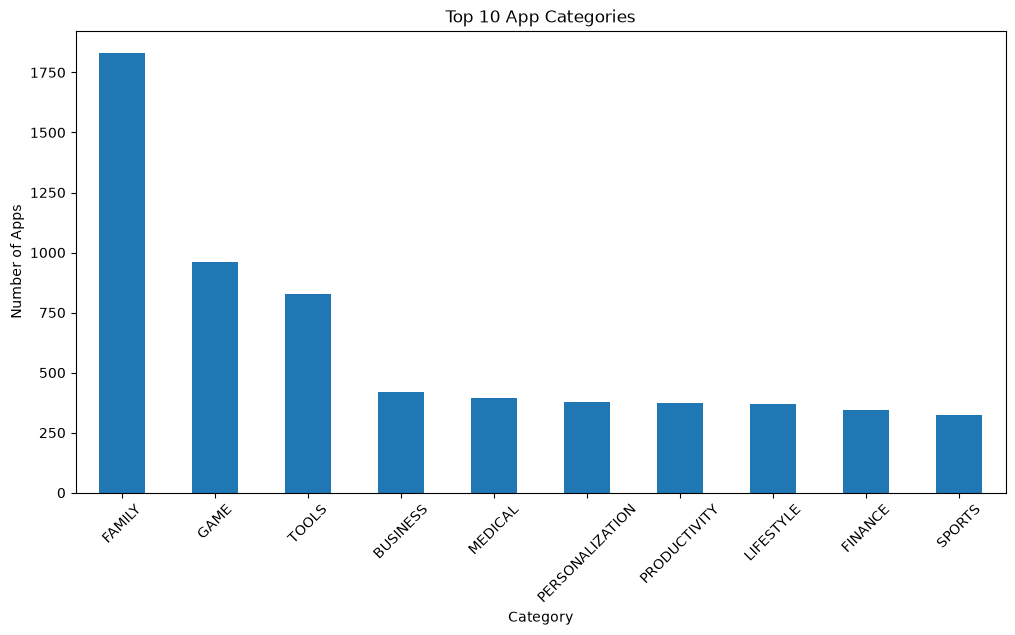

In [26]:
plt.figure(figsize=(12, 6))

category_counts.head(10).plot(kind='bar')

plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')

plt.xticks(rotation=45)

plt.show()

In [27]:
## Clean Reviews

print(df['Reviews'].dtype)

str


In [28]:
df['Reviews'] = pd.to_numeric(
    df['Reviews'],
    errors='coerce'
)

print("Missing Reviews:", df['Reviews'].isnull().sum())

Missing Reviews: 1


In [32]:
print(df[df['Installs'] == 'Free'][['App', 'Installs']])

                                           App Installs
10472  Life Made WI-Fi Touchscreen Photo Frame     Free


In [33]:
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Installs'] = pd.to_numeric(
    df['Installs'],
    errors='coerce'
)

print("Missing Installs after conversion:")
print(df['Installs'].isnull().sum())

Missing Installs after conversion:
1


In [34]:
print(df[df['Installs'].isnull()][['App', 'Installs', 'Type']])

                                           App  Installs Type
10472  Life Made WI-Fi Touchscreen Photo Frame       NaN    0


In [36]:
df = df.dropna(subset=['Installs'])

df['Installs'] = df['Installs'].astype(int)

print("Installs dtype:", df['Installs'].dtype)
print("Dataset shape:", df.shape)

Installs dtype: int64
Dataset shape: (9659, 13)


In [37]:
## Price


df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)


df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)


print("Price dtype:", df['Price'].dtype)
print("Missing Price:", df['Price'].isnull().sum())

Price dtype: float64
Missing Price: 0


In [39]:
## Check everything
print(df[['Reviews', 'Installs', 'Price']].dtypes)
print(df[['Reviews', 'Installs', 'Price']].head())

Reviews     float64
Installs      int64
Price       float64
dtype: object
    Reviews  Installs  Price
0     159.0     10000    0.0
1     967.0    500000    0.0
2   87510.0   5000000    0.0
3  215644.0  50000000    0.0
4     967.0    100000    0.0


In [50]:
## Free vs Paid Apps
print("Free vs Paid Apps:")
print(df['Type'].value_counts())

Free vs Paid Apps:
Type
Free    8903
Paid     756
Name: count, dtype: int64


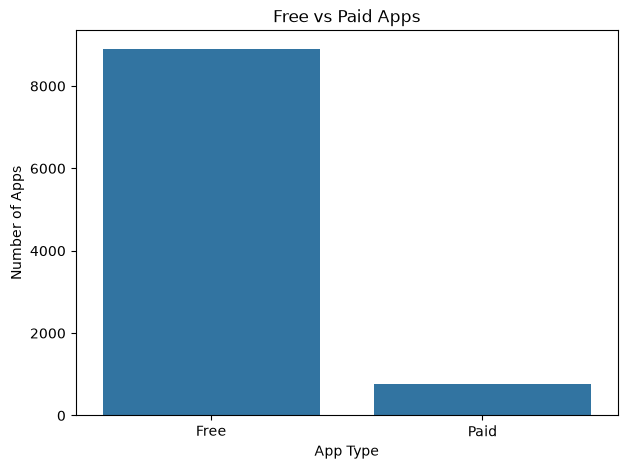

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Type'
)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.show()

In [52]:
## Top 10 Most Installed Apps
top_installed = df.sort_values(
    'Installs',
    ascending=False
)


print(
    top_installed[
        ['App', 'Category', 'Installs', 'Rating']
    ].head(10)
)

                          App             Category    Installs  Rating
3736              Google News   NEWS_AND_MAGAZINES  1000000000     3.9
2554                  Google+               SOCIAL  1000000000     4.2
1654           Subway Surfers                 GAME  1000000000     4.5
152         Google Play Books  BOOKS_AND_REFERENCE  1000000000     3.9
3665                  YouTube        VIDEO_PLAYERS  1000000000     4.3
2545                Instagram               SOCIAL  1000000000     4.5
3687  Google Play Movies & TV        VIDEO_PLAYERS  1000000000     3.7
2808            Google Photos          PHOTOGRAPHY  1000000000     4.5
3127       Google Street View     TRAVEL_AND_LOCAL  1000000000     4.2
865         Google Play Games        ENTERTAINMENT  1000000000     4.3


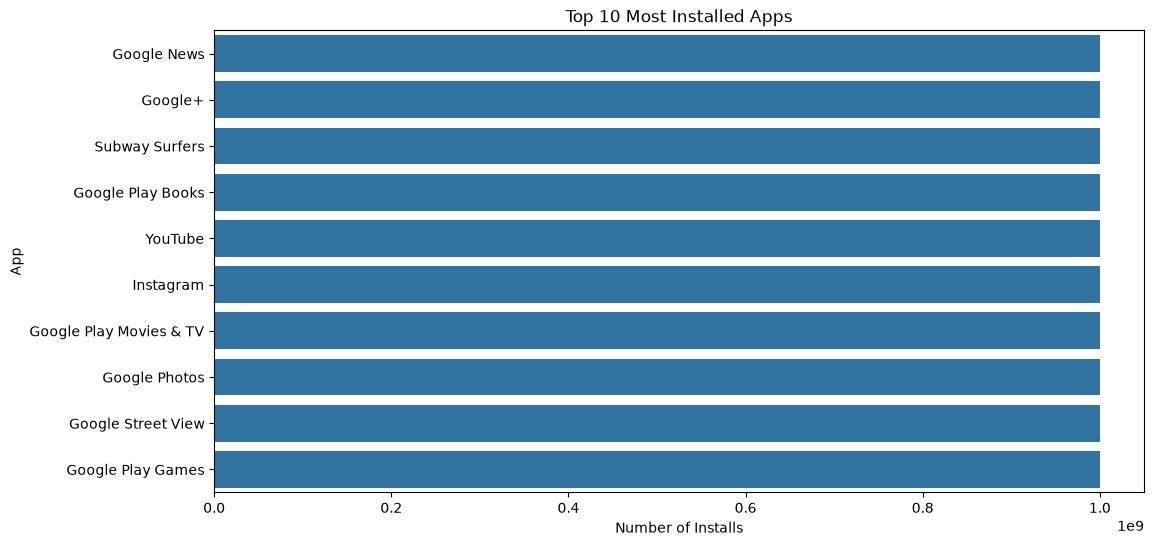

In [53]:
plt.figure(figsize=(12, 6))

top_10 = top_installed.head(10)

sns.barplot(
    data=top_10,
    x='Installs',
    y='App'
)

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.show()

In [45]:
## Top 10 Most Reviewed Apps
top_reviews = df.sort_values(
    'Reviews',
    ascending=False
)


print(
    top_reviews[
        ['App', 'Category', 'Reviews', 'Rating']
    ].head(10)
)

                                                    App       Category  \
2544                                           Facebook         SOCIAL   
336                                  WhatsApp Messenger  COMMUNICATION   
2545                                          Instagram         SOCIAL   
335            Messenger – Text and Video Chat for Free  COMMUNICATION   
1670                                     Clash of Clans           GAME   
4005            Clean Master- Space Cleaner & Antivirus          TOOLS   
1654                                     Subway Surfers           GAME   
3665                                            YouTube  VIDEO_PLAYERS   
7536  Security Master - Antivirus, VPN, AppLock, Boo...          TOOLS   
1660                                       Clash Royale           GAME   

         Reviews  Rating  
2544  78158306.0     4.1  
336   69119316.0     4.4  
2545  66577313.0     4.5  
335   56642847.0     4.0  
1670  44891723.0     4.6  
4005  42916526.0     4.

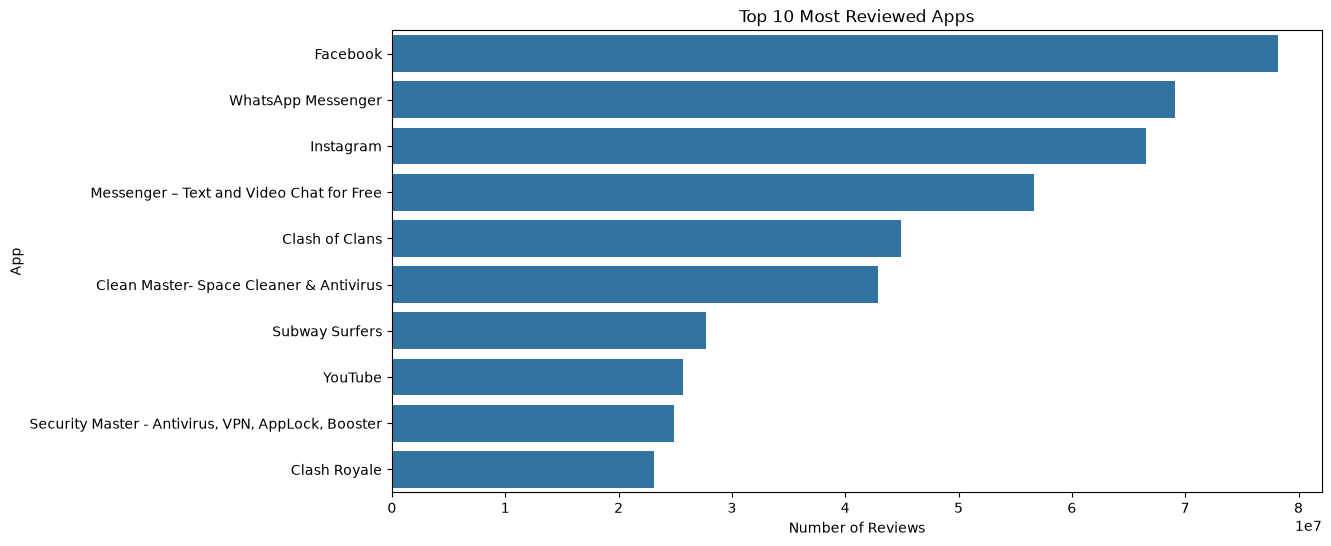

In [46]:
plt.figure(figsize=(12, 6))

top_10_reviews = top_reviews.head(10)

sns.barplot(
    data=top_10_reviews,
    x='Reviews',
    y='App'
)

plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

plt.show()

In [47]:
## Average Rating by Category
category_rating = (
    df.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)


print("Top 10 Categories by Average Rating:")
print(category_rating.head(10))

Top 10 Categories by Average Rating:
Category
EVENTS                 4.395313
EDUCATION              4.363866
ART_AND_DESIGN         4.354687
BOOKS_AND_REFERENCE    4.334234
PERSONALIZATION        4.325532
PARENTING              4.300000
BEAUTY                 4.283019
SOCIAL                 4.255230
HEALTH_AND_FITNESS     4.251736
GAME                   4.249948
Name: Rating, dtype: float64


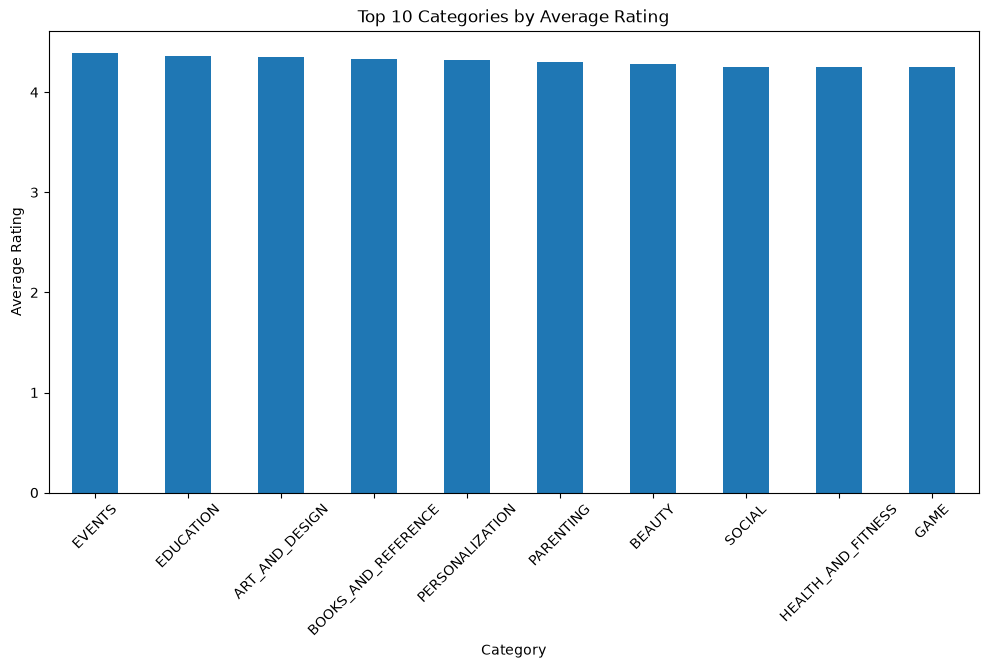

In [48]:
plt.figure(figsize=(12, 6))

category_rating.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')

plt.xticks(rotation=45)

plt.show()

In [54]:
## Average Reviews by Category
category_reviews = (
    df.groupby('Category')['Reviews']
    .mean()
    .sort_values(ascending=False)
)


print("Top 10 Categories by Average Reviews:")
print(category_reviews.head(10))

Top 10 Categories by Average Reviews:
Category
SOCIAL           953672.807531
COMMUNICATION    907337.676190
GAME             648903.763295
VIDEO_PLAYERS    414015.754601
PHOTOGRAPHY      374915.551601
ENTERTAINMENT    340810.294118
TOOLS            277335.644498
SHOPPING         220553.118812
WEATHER          155634.987342
PRODUCTIVITY     148638.098930
Name: Reviews, dtype: float64


In [56]:
## Free vs Paid Average Rating

type_rating = (
    df.groupby('Type')['Rating']
    .mean()
)


print("Average Rating by App Type:")
print(type_rating)

Average Rating by App Type:
Type
Free    4.186050
Paid    4.267725
Name: Rating, dtype: float64


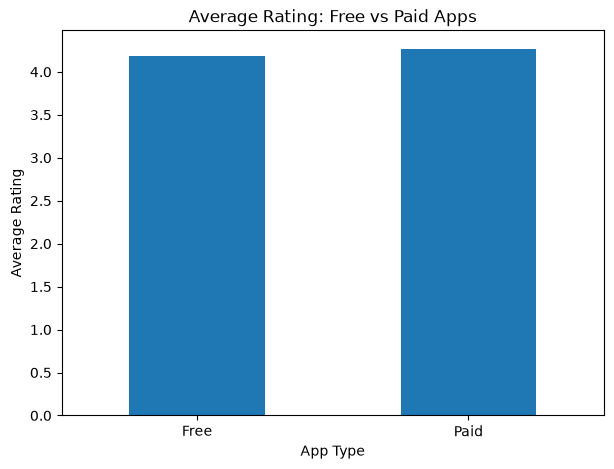

In [57]:
plt.figure(figsize=(7, 5))

type_rating.plot(kind='bar')

plt.title('Average Rating: Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Rating')

plt.xticks(rotation=0)

plt.show()

In [58]:
## Average Installs by Category
category_installs = (
    df.groupby('Category')['Installs']
    .mean()
    .sort_values(ascending=False)
)


print("Top 10 Categories by Average Installs:")
print(category_installs.head(10))

Top 10 Categories by Average Installs:
Category
COMMUNICATION         3.504215e+07
VIDEO_PLAYERS         2.409143e+07
SOCIAL                2.296179e+07
ENTERTAINMENT         2.072216e+07
PHOTOGRAPHY           1.654501e+07
PRODUCTIVITY          1.548955e+07
GAME                  1.447229e+07
TRAVEL_AND_LOCAL      1.321866e+07
TOOLS                 9.675661e+06
NEWS_AND_MAGAZINES    9.327629e+06
Name: Installs, dtype: float64


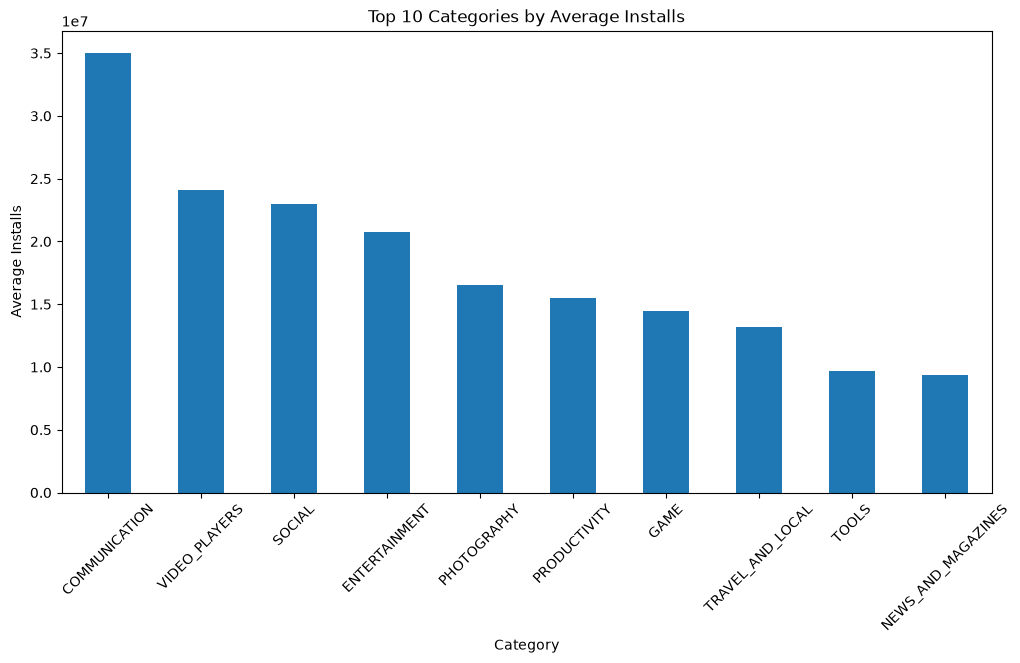

In [60]:
plt.figure(figsize=(12, 6))

category_installs.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Categories by Average Installs')
plt.xlabel('Category')
plt.ylabel('Average Installs')

plt.xticks(rotation=45)

plt.show()

In [62]:
## Free vs Paid Install Comparison
type_installs = (
    df.groupby('Type')['Installs']
    .mean()
)


print("Average Installs by App Type:")
print(type_installs)

Average Installs by App Type:
Type
Free    8.431492e+06
Paid    7.587947e+04
Name: Installs, dtype: float64


In [63]:
## Correlation Analysis

numeric_cols = [
    'Rating',
    'Reviews',
    'Installs',
    'Price'
]


correlation = df[numeric_cols].corr()


print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
            Rating   Reviews  Installs     Price
Rating    1.000000  0.050207  0.034307 -0.018662
Reviews   0.050207  1.000000  0.625165 -0.007598
Installs  0.034307  0.625165  1.000000 -0.009405
Price    -0.018662 -0.007598 -0.009405  1.000000


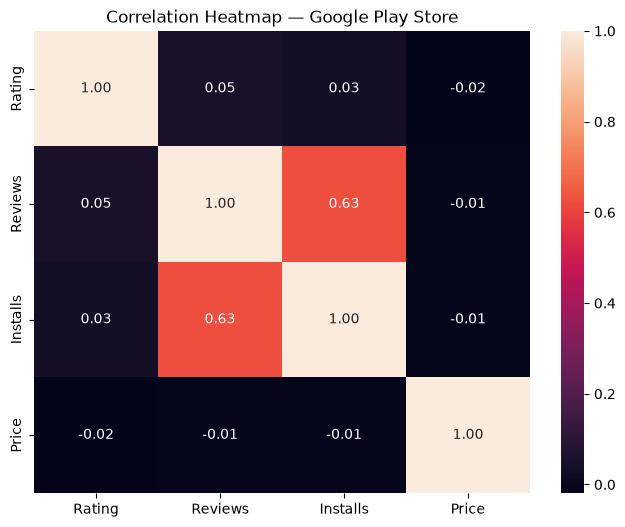

In [65]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Heatmap — Google Play Store')

plt.show()

In [66]:
## Most Expensive Apps
expensive_apps = df.sort_values(
    'Price',
    ascending=False
)


print(
    expensive_apps[
        ['App', 'Category', 'Price', 'Rating']
    ].head(10)
)

                                    App   Category   Price  Rating
4367           I'm Rich - Trump Edition  LIFESTYLE  400.00     3.6
9934  I'm Rich/Eu sou Rico/أنا غني/我很有錢  LIFESTYLE  399.99     4.3
5354                     I am Rich Plus     FAMILY  399.99     4.0
5351                          I am rich  LIFESTYLE  399.99     3.8
5369                          I am Rich    FINANCE  399.99     4.3
5373                 I AM RICH PRO PLUS    FINANCE  399.99     4.0
4197             most expensive app (H)     FAMILY  399.99     4.3
5359                 I am rich(premium)    FINANCE  399.99     3.5
5362                      I Am Rich Pro     FAMILY  399.99     4.4
5356                  I Am Rich Premium    FINANCE  399.99     4.1


In [67]:
## Paid Apps Analysis

paid_apps = df[df['Type'] == 'Paid']

print("Number of paid apps:", len(paid_apps))

print("\nAverage paid app price:")
print(paid_apps['Price'].mean())

print("\nAverage paid app rating:")
print(paid_apps['Rating'].mean())

print("\nAverage paid app installs:")
print(paid_apps['Installs'].mean())

Number of paid apps: 756

Average paid app price:
14.045145502645504

Average paid app rating:
4.267724867724867

Average paid app installs:
75879.47222222222


In [68]:
# Key Insights

## 1. Free vs Paid Apps

The dataset contains significantly more free applications than paid applications.

- Free apps: 8,903
- Paid apps: 756

This shows that the free application model is dominant in this dataset.

## 2. App Categories

The FAMILY category contains the largest number of applications, followed by GAME and TOOLS.

## 3. User Engagement

SOCIAL has the highest average number of reviews among the categories analyzed, followed by COMMUNICATION and GAME.

This suggests that social and communication applications receive very high levels of user engagement.

## 4. Ratings

The EVENTS category has the highest average rating among the categories analyzed, followed by EDUCATION and ART_AND_DESIGN.

## 5. Installations

Several applications have reached 1 billion installations, showing the extremely large user base of some Google Play Store applications.

## 6. Most Reviewed Apps

Facebook has the highest number of reviews in the cleaned dataset, followed by WhatsApp Messenger and Instagram.

## 7. Pricing

The majority of applications are free, while a smaller portion are paid applications.

SyntaxError: invalid syntax (3525092769.py, line 5)

In [ ]:
# Conclusion

This project analyzed Google Play Store applications using Python and data analysis techniques.

The original dataset contained 10,841 records and 13 columns. Duplicate applications and missing values were identified and handled during the data-cleaning process.

After cleaning, the dataset contained 9,660 application records with no missing values.

The analysis examined:

- App categories
- Ratings
- Reviews
- Installations
- Free vs Paid applications
- Average ratings by category
- Average reviews by category
- Average installations by category
- App pricing
- Correlations between numerical variables

The analysis showed that FAMILY was the largest category by number of applications. SOCIAL had the highest average number of reviews, while EVENTS had the highest average rating among the analyzed categories.

The dataset was dominated by free applications, with 8,903 free apps compared with 756 paid apps.

Overall, this project demonstrates practical skills in data cleaning, exploratory data analysis, visualization, grouping, aggregation, correlation analysis, and extracting meaningful insights from a real-world dataset.